In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
#loading Dataset
df = pd.read_csv("final_dataset.csv")
print(df.shape)
df.head()

(1050, 15)


,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,03-01-2024,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,04-02-2025,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,25-08-2024,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,05-01-2025,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,09-04-2025,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [18]:
# 2. DATE COLUMN PROCESSING
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [20]:
# Aggregate daily sales
daily_sales = df.groupby('Date')['Total_Amount'].sum().asfreq('D').ffill()
daily_sales = daily_sales.reset_index()
daily_sales.columns = ['ds', 'y']
print(daily_sales.head())

          ds         y
0 2024-01-01   4061.05
1 2024-01-02   4326.18
2 2024-01-03  10197.08
3 2024-01-04   5632.04
4 2024-01-05   5354.86


In [21]:
# 3. Prophet Model (Trend + Seasonality)
# -----------------------------
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(daily_sales)

# Forecast entire period to get trend + seasonality
future_all = prophet_model.make_future_dataframe(periods=0)
forecast_all = prophet_model.predict(future_all)

# Residuals (irregular spikes)
daily_sales['residual'] = daily_sales['y'] - forecast_all['yhat']

16:31:06 - cmdstanpy - INFO - Chain [1] start processing
16:31:07 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
# 4. Feature Engineering for XGBoost
# -----------------------------
def create_features_residual(df, lags=14):
    df_feat = pd.DataFrame(df['residual'])
    df_feat['day_of_week'] = df['ds'].dt.dayofweek
    df_feat['month'] = df['ds'].dt.month
    # Lag features
    for lag in range(1, lags+1):
        df_feat[f'lag_{lag}'] = df_feat['residual'].shift(lag)
    # Rolling averages
    df_feat['roll_mean_7'] = df_feat['residual'].shift(1).rolling(7).mean()
    df_feat['roll_mean_14'] = df_feat['residual'].shift(1).rolling(14).mean()
    df_feat = df_feat.dropna()
    return df_feat

df_feat = create_features_residual(daily_sales)
target_index = df_feat.index  # To align with dates

In [23]:
# 4. Train-Test Split
# -----------------------------
train = df_feat.iloc[:-30]
test = df_feat.iloc[-30:]

X_train = train.drop('residual', axis=1)
y_train = train['residual']
X_test = test.drop('residual', axis=1)
y_test = test['residual']


In [24]:
# 5. Train XGBoost Model
# -----------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)




,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
# 7. Predict Test Set Residuals
# -----------------------------
residual_pred_test = xgb_model.predict(X_test)

# Final test prediction = Prophet trend + XGBoost residual
y_test_pred = forecast_all['yhat'].iloc[target_index[-30:]].values + residual_pred_test

# Display predicted values
#print("Predicted values for the last 30 days:")
#print(residual_pred_test)

In [29]:
# Accuracy metrics
mae = mean_absolute_error(daily_sales['y'].iloc[target_index[-30:]], y_test_pred)
rmse = np.sqrt(mean_squared_error(daily_sales['y'].iloc[target_index[-30:]], y_test_pred))
mape = np.mean(np.abs((daily_sales['y'].iloc[target_index[-30:]] - y_test_pred) /
                       daily_sales['y'].iloc[target_index[-30:]])) * 100

print(f"\nHybrid Test-set Accuracy Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


Hybrid Test-set Accuracy Metrics:
MAE: 2602.30
RMSE: 3553.59
MAPE: 104.71%


In [30]:
# 8. Forecast Next 10 Days
# -----------------------------
future_dates = pd.date_range(start=daily_sales['ds'].iloc[-1]+pd.Timedelta(days=1), periods=10)

# Prophet forecast for next 10 days
future_prophet = prophet_model.make_future_dataframe(periods=10)
future_forecast = prophet_model.predict(future_prophet)
future_trend = future_forecast['yhat'].iloc[-10:].values

# Prepare XGBoost features recursively
last_values = daily_sales['residual'].iloc[-14:].tolist()
future_residuals = []

for i in range(10):
    day_of_week = future_dates[i].dayofweek
    month = future_dates[i].month
    lag_features = last_values[-14:]
    roll_mean_7 = np.mean(last_values[-7:])
    roll_mean_14 = np.mean(last_values)
    
    input_array = np.array([day_of_week, month] + lag_features + [roll_mean_7, roll_mean_14]).reshape(1, -1)
    pred_residual = xgb_model.predict(input_array)[0]
    future_residuals.append(pred_residual)
    last_values.append(pred_residual)

# Final forecast = Prophet trend + XGBoost residual
future_pred = future_trend + np.array(future_residuals)
future_series = pd.Series(future_pred, index=future_dates)

print("\nHybrid Forecast for Next 10 Days:")
print(future_series)


Hybrid Forecast for Next 10 Days:
2025-12-30    3648.853629
2025-12-31    3851.053761
2026-01-01    3702.704977
2026-01-02    2271.580067
2026-01-03    2094.374066
2026-01-04    4137.760249
2026-01-05    6088.591147
2026-01-06    6202.361479
2026-01-07    3059.602758
2026-01-08    4926.716102
Freq: D, dtype: float64


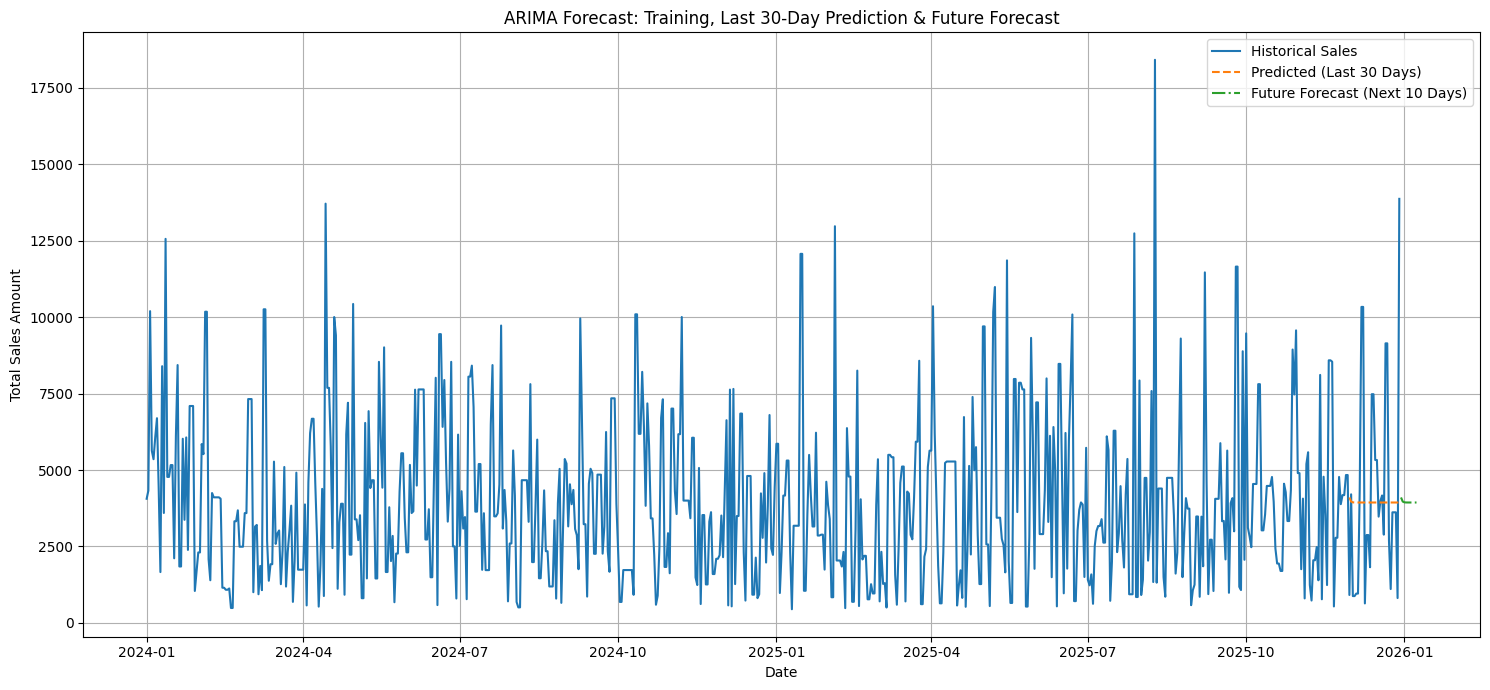

In [40]:
# 9. Plot Historical, Test & Future Forecast
# -----------------------------
plt.figure(figsize=(15,7))
plt.plot(daily_sales['ds'], daily_sales['y'], label='Historical Sales', color='blue')
plt.plot(daily_sales['ds'].iloc[target_index[-30:]], y_test_pred, label='Predicted (Last 30 Days)', linestyle='dashed', color='orange')
plt.plot(future_series.index, future_series.values, label='Future Forecast (Next 10 Days)', linestyle='dashdot', color='green')
plt.title("Hybrid Prophet + XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()